In [71]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn model selection and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Decision Tree specific
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [3]:
df=pd.read_csv(r"C:\Users\Lenovo\Desktop\LMS_PROJECT\Decision Tree Project\Decision Tree Project\Dataset\HeartDisease.csv")
df.sample(5)

,age,gender,chest_pain,rest_bps,cholestrol,fasting_blood_sugar,rest_ecg,thalach,exer_angina,old_peak,slope,ca,thalassemia,target
91,57,1,0,132,207,0,1,168,1,0.0,2,0,3,1
242,64,1,0,145,212,0,0,132,0,2.0,1,2,1,0
120,64,0,0,130,303,0,1,122,0,2.0,1,2,2,1
65,35,0,0,138,183,0,1,182,0,1.4,2,0,2,1
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  303 non-null    int64  
 1   gender               303 non-null    int64  
 2   chest_pain           303 non-null    int64  
 3   rest_bps             303 non-null    int64  
 4   cholestrol           303 non-null    int64  
 5   fasting_blood_sugar  303 non-null    int64  
 6   rest_ecg             303 non-null    int64  
 7   thalach              303 non-null    int64  
 8   exer_angina          303 non-null    int64  
 9   old_peak             303 non-null    float64
 10  slope                303 non-null    int64  
 11  ca                   303 non-null    int64  
 12  thalassemia          303 non-null    int64  
 13  target               303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


# We seen that there all variables are numeric

# EDA

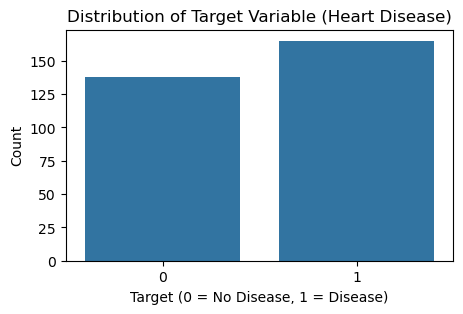

In [31]:
# Plot target variable distribution
plt.figure(figsize=(5, 3))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable (Heart Disease)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.show()

# Percentage distribution
#print("\nTarget variable distribution (%):\n", df['target'].value_counts(normalize=True) * 100)

### The dataset is nearly balanced (54.45% vs. 45.54%), which is good for model training.



<Axes: xlabel='gender', ylabel='target'>

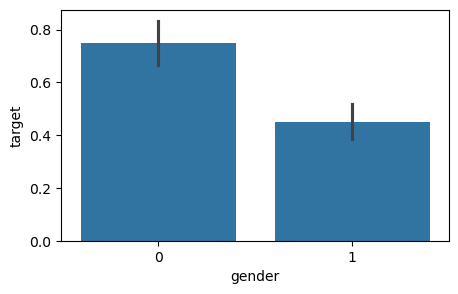

In [17]:
plt.figure(figsize=(5, 3))
sns.barplot(x=df.gender,y=df.target)


### As we sen that males has higher chance of heart diseease than females

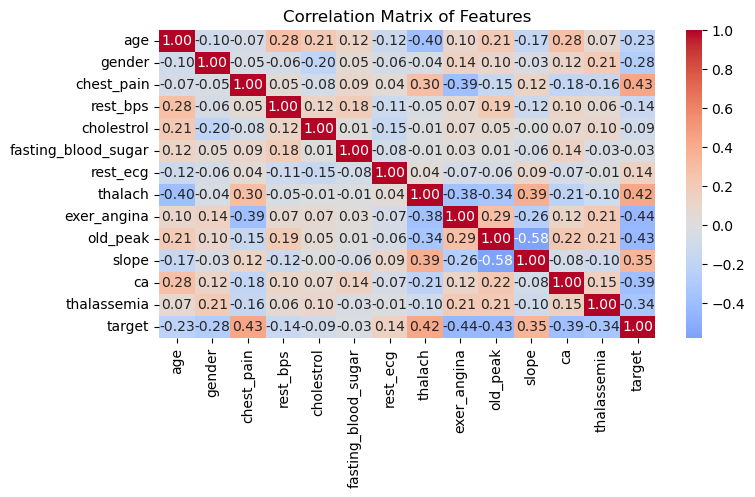

In [28]:
# Calculate correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

# Top correlations with target
#print("\nTop correlations with target:\n", corr_matrix['target'].sort_values(ascending=False))

### As we see that there is no Highly correleted variables are present in data

In [35]:
# Model Building

In [37]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split into train & test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
dt_model = DecisionTreeClassifier(random_state=17)
dt_model.fit(X_train, y_train)

# Predictions
y_pred = dt_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
#print("F1-Score:", f1_score(y_test, y_pred))
# print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8032786885245902
Precision: 0.8571428571428571
Recall: 0.75


### We get 80% accuracy on test data

## hyper parameter tuning 

In [51]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

# Train with best parameters
best_dt_model = grid_search.best_estimator_
y_pred_tuned = best_dt_model.predict(X_test)

# Evaluate tuned model
print("\nTuned Model Performance:")
print(classification_report(y_test, y_pred_tuned))

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

Tuned Model Performance:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79        29
           1       0.83      0.75      0.79        32

    accuracy                           0.79        61
   macro avg       0.79      0.79      0.79        61
weighted avg       0.79      0.79      0.79        61



### The tuned Decision Tree model achieves 79% accuracy with balanced precision and recall (~0.79 F1-score for both classes), indicating robust performance in predicting heart disease.

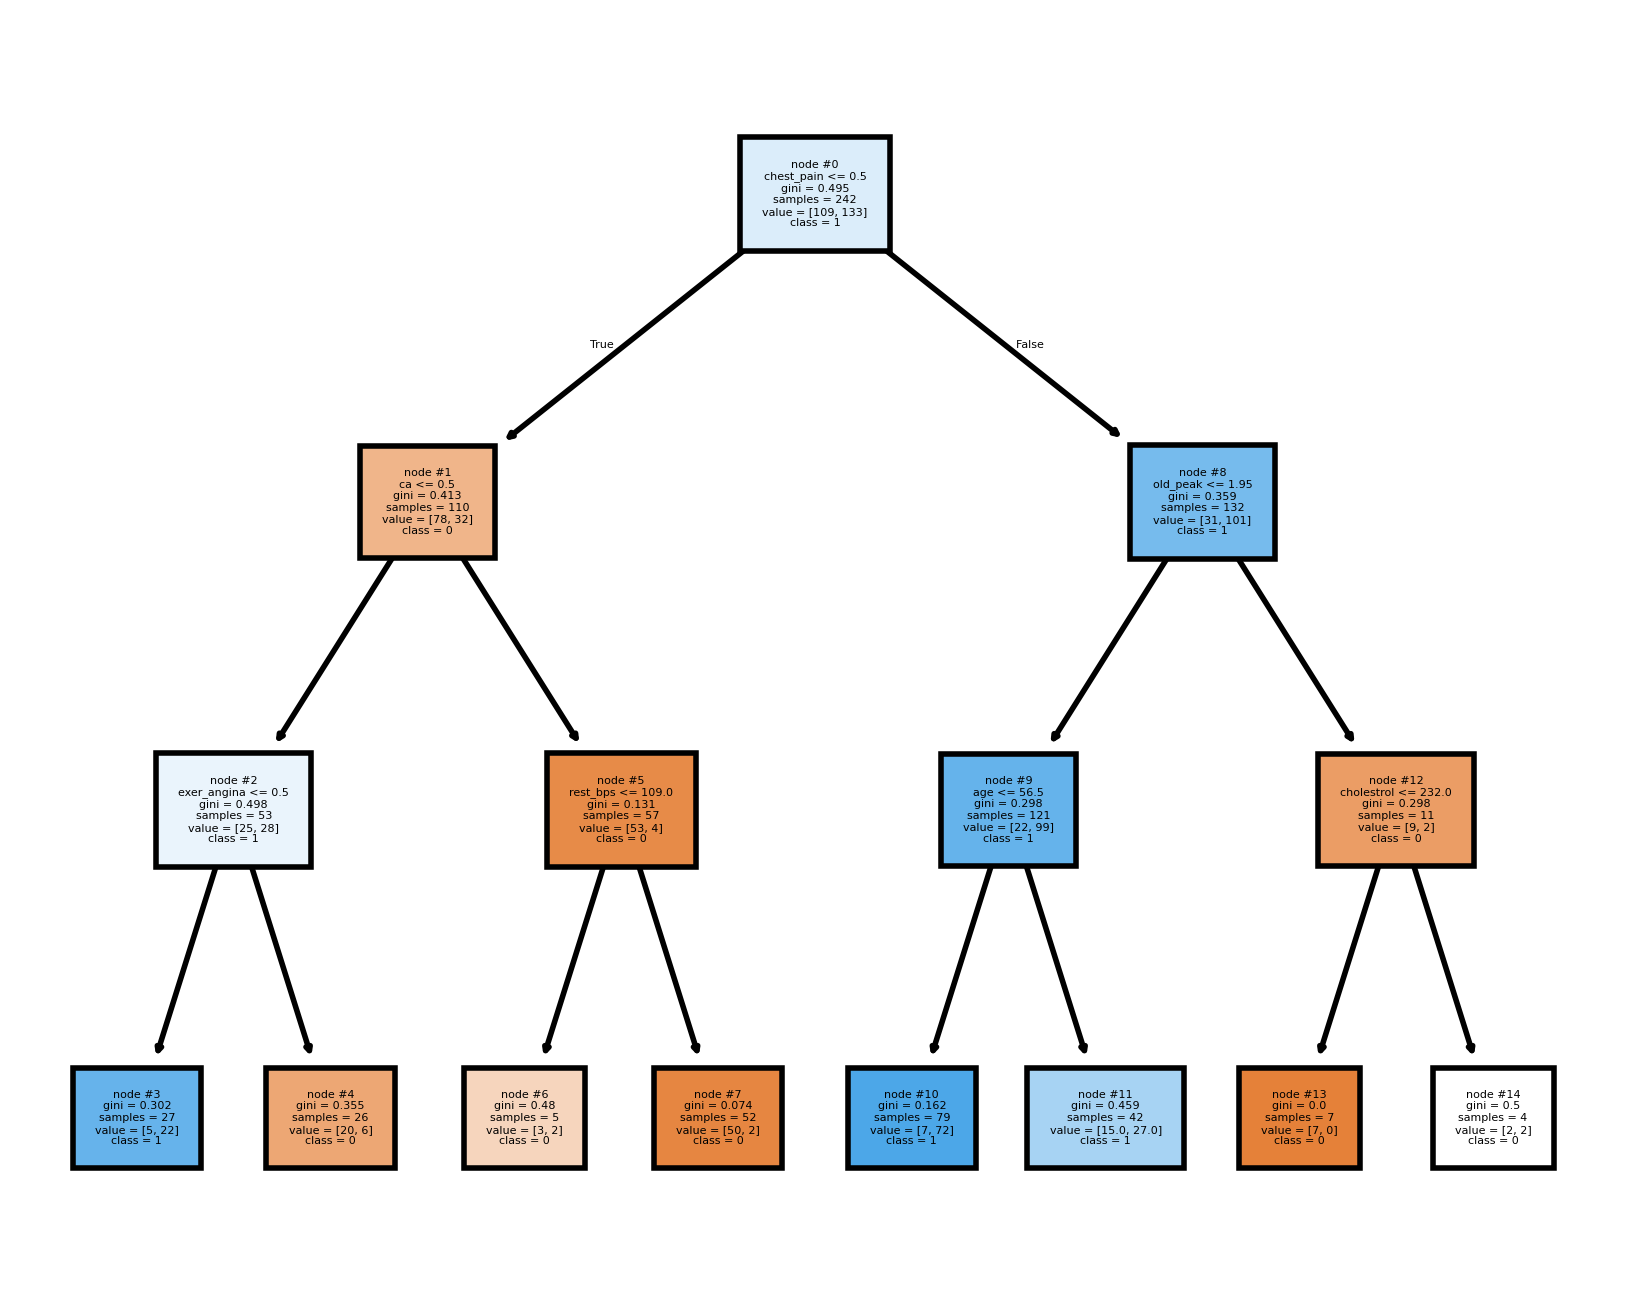

In [69]:
#Tree Visualization
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,4), dpi=400)
plot_tree(best_dt_model,
          feature_names = list(X.columns),
          class_names = ['0', '1'],
          filled = True,
          node_ids=True,
          fontsize=2);
